In [3]:
!pip install -U ultralytics pycocotools -q

In [4]:
!nvidia-smi
from ultralytics import YOLO
import ultralytics
ultralytics.checks()

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)


In [5]:
from google.colab import files
files.upload()  # faça upload do kaggle.json aqui

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d ammarnassanalhajali/pklot-dataset
!unzip -q pklot-dataset.zip -d /content/pklot
!ls /content/pklot

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ammarnassanalhajali/pklot-dataset
License(s): unknown
100% 843M/843M [00:07<00:00, 125MB/s]

README.dataset.txt  README.roboflow.txt  test  train  valid


In [6]:
import json, os
from pathlib import Path

def coco_to_yolo(json_path, output_dir):
    with open(json_path) as f:
        data = json.load(f)

    # Filtrar supercategoria (supercategory != 'none' = classes folha)
    leaf_cats = [cat for cat in data['categories']
                 if cat['supercategory'] != 'none']
    categories = {cat['id']: i for i, cat in enumerate(leaf_cats)}
    # Resultado: {1: 0 (space-empty), 2: 1 (space-occupied)}
    print(f"Mapeamento ID→classe YOLO: {categories}")
    print(f"Classes: {[cat['name'] for cat in leaf_cats]}")

    images = {img['id']: img for img in data['images']}

    ann_by_image = {}
    for ann in data['annotations']:
        ann_by_image.setdefault(ann['image_id'], []).append(ann)

    os.makedirs(output_dir, exist_ok=True)

    for img_id, img_info in images.items():
        W, H = img_info['width'], img_info['height']
        fname = Path(img_info['file_name']).stem
        lines = []
        for ann in ann_by_image.get(img_id, []):
            if ann['category_id'] not in categories:
                continue  # pular supercategoria "spaces" (id=0)
            cls = categories[ann['category_id']]
            x, y, w, h = ann['bbox']
            x_c = (x + w/2) / W
            y_c = (y + h/2) / H
            w_n = w / W
            h_n = h / H
            lines.append(f"{cls} {x_c:.6f} {y_c:.6f} {w_n:.6f} {h_n:.6f}")
        with open(os.path.join(output_dir, fname + '.txt'), 'w') as f:
            f.write('\n'.join(lines))

    print(f"✅ {len(images)} imagens convertidas → {output_dir}")

for split in ['train', 'valid', 'test']:
    coco_to_yolo(
        f'/content/pklot/{split}/_annotations.coco.json',
        f'/content/pklot/{split}'
    )

Mapeamento ID→classe YOLO: {1: 0, 2: 1}
Classes: ['space-empty', 'space-occupied']
✅ 8691 imagens convertidas → /content/pklot/train
Mapeamento ID→classe YOLO: {1: 0, 2: 1}
Classes: ['space-empty', 'space-occupied']
✅ 2483 imagens convertidas → /content/pklot/valid
Mapeamento ID→classe YOLO: {1: 0, 2: 1}
Classes: ['space-empty', 'space-occupied']
✅ 1242 imagens convertidas → /content/pklot/test


In [7]:
yaml_content = """
path: /content/pklot
train: train
val: valid
test: test

nc: 2
names:
  0: Vazio
  1: Ocupado
"""

with open('/content/parking.yaml', 'w') as f:
    f.write(yaml_content)

print("✅ data.yaml criado!")

✅ data.yaml criado!


In [8]:
from ultralytics import YOLO

model = YOLO('yolo26m.pt')

results = model.train(
    data='/content/parking.yaml',
    epochs=40,
    imgsz=416,
    batch=16,
    workers=2,
    cache=True,
    name='parking_monitor_Yolom',
    device=0,
    patience=10,
    save=True,
    plots=True
)

print("✅ Treinamento concluído!")

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/parking.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=parking_monitor_Yolom, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

In [9]:
metrics = model.val()
print(f"mAP50:     {metrics.box.map50:.3f}")
print(f"mAP50-95:  {metrics.box.map:.3f}")
print(f"Precision: {metrics.box.mp:.3f}")
print(f"Recall:    {metrics.box.mr:.3f}")

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m summary (fused): 132 layers, 20,350,994 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 35.4±10.2 MB/s, size: 73.6 KB)
val: Scanning /content/pklot/valid.cache... 2483 images, 59 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2483/2483 1.2Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 156/156 2.8it/s 55.0s
                   all       2483     143316      0.998      0.998      0.995      0.993
                 Vazio       2062      73629      0.998      0.997      0.995      0.994
               Ocupado       1967      69687      0.998      0.998      0.995      0.992
Speed: 0.5ms preprocess, 14.3ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/runs/detect/val
mAP50:     0.995
mAP50-95:  0.993
Precision: 0.998
Recall:    0.998


In [10]:
from google.colab import drive
drive.mount('/content/drive')

!cp /content/runs/detect/parking_monitor_Yolom/weights/best.pt \
    "/content/drive/MyDrive/parking_yolo26m_best.pt"

print("✅ Modelo salvo no Drive!")

Mounted at /content/drive
✅ Modelo salvo no Drive!


In [11]:
import shutil
shutil.copytree(
    '/content/runs/detect/parking_monitor_Yolom',
    '/content/drive/MyDrive/parking_monitor_resultados_Yolo26m',
    dirs_exist_ok=True
)
print("✅ Resultados completos salvos no Drive!")

✅ Resultados completos salvos no Drive!



image 1/1 /content/pklot/test/2012-10-27_11_00_49_jpg.rf.229fb671ec16af21b738eb6eae7d2120.jpg: 416x416 49 Vazios, 52 Ocupados, 22.4ms
Speed: 5.8ms preprocess, 22.4ms inference, 5.6ms postprocess per image at shape (1, 3, 416, 416)


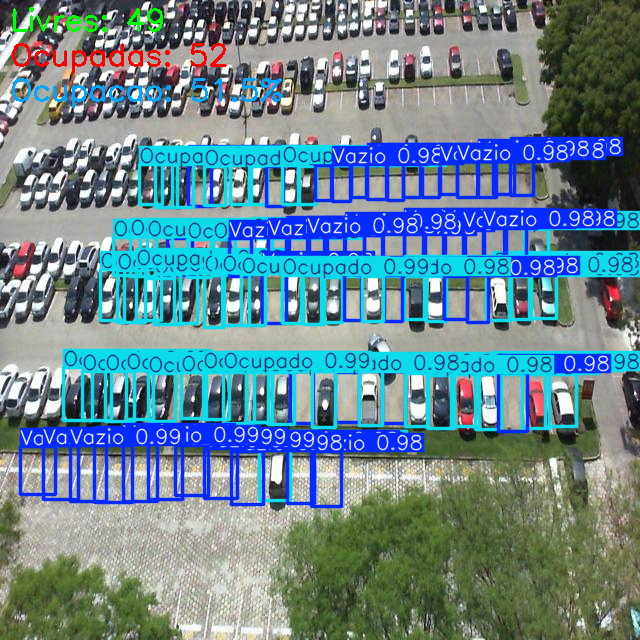


🅿️  Total: 101 | 🟢 Livres: 49 | 🔴 Ocupadas: 52 | 📊 51.5%


In [12]:
import glob
from google.colab.patches import cv2_imshow
import cv2

# Pegar uma imagem de teste
test_images = glob.glob('/content/pklot/test/*.jpg')
img_path = test_images[17]

# Carregar melhor modelo
model = YOLO('/content/runs/detect/parking_monitor_Yolom/weights/best.pt')

# Inferência
results = model(img_path, conf=0.5)[0]

empty    = sum(1 for c in results.boxes.cls if int(c) == 0)
occupied = sum(1 for c in results.boxes.cls if int(c) == 1)
total    = empty + occupied
pct      = (occupied / total * 100) if total > 0 else 0

# Desenhar
img = results.plot()
cv2.putText(img, f"Livres: {empty}",      (10, 30),  cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
cv2.putText(img, f"Ocupadas: {occupied}", (10, 65),  cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,255), 2)
cv2.putText(img, f"Ocupacao: {pct:.1f}%", (10, 100), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,165,0), 2)

cv2_imshow(img)
print(f"\n🅿️  Total: {total} | 🟢 Livres: {empty} | 🔴 Ocupadas: {occupied} | 📊 {pct:.1f}%")

In [13]:
from google.colab import drive
drive.mount('/content/drive')

import os
results_dir = '/content/drive/MyDrive/parking_monitor_resultados_Yolo26m'
print(os.listdir(results_dir))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['val_batch0_labels.jpg', 'train_batch1.jpg', 'BoxR_curve.png', 'train_batch0.jpg', 'BoxPR_curve.png', 'results.png', 'val_batch0_pred.jpg', 'val_batch1_labels.jpg', 'labels.jpg', 'confusion_matrix.png', 'train_batch16320.jpg', 'val_batch2_labels.jpg', 'args.yaml', 'val_batch1_pred.jpg', 'weights', 'confusion_matrix_normalized.png', 'train_batch16322.jpg', 'results.csv', 'BoxP_curve.png', 'train_batch16321.jpg', 'BoxF1_curve.png', 'val_batch2_pred.jpg', 'train_batch2.jpg']


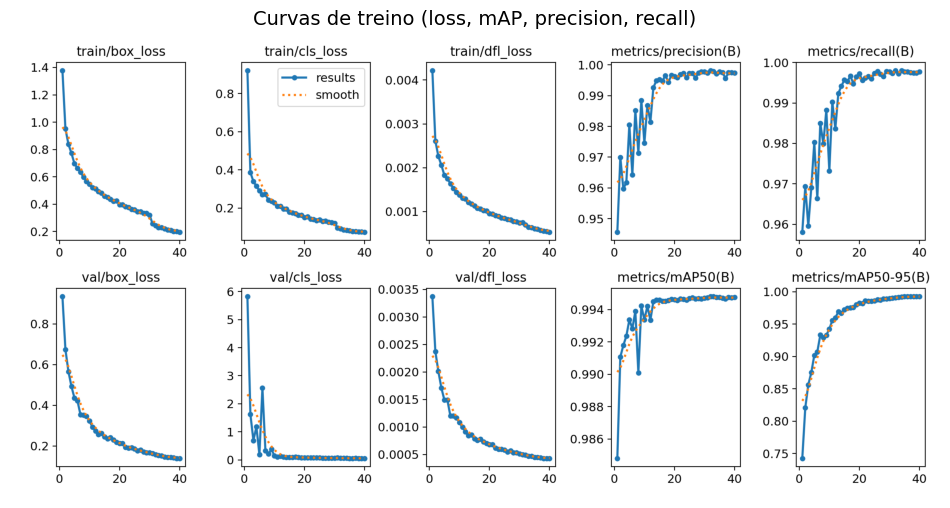

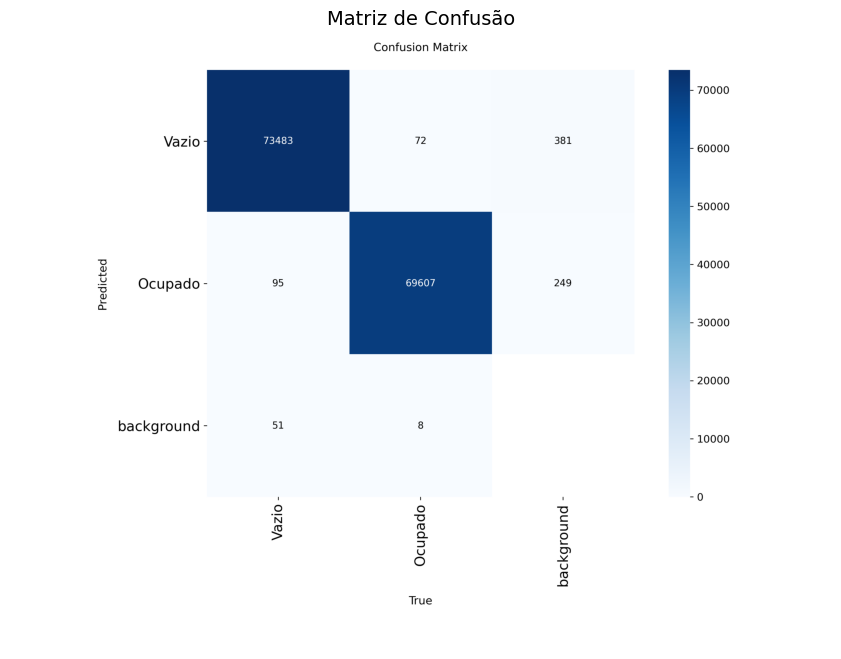

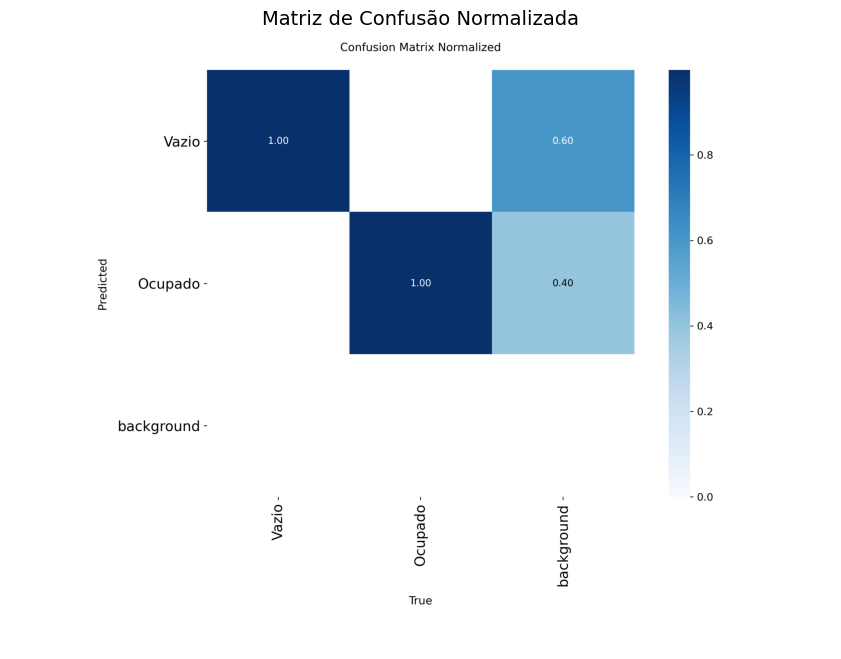

⚠️ Não encontrado: PR_curve.png
⚠️ Não encontrado: F1_curve.png
⚠️ Não encontrado: P_curve.png
⚠️ Não encontrado: R_curve.png


In [14]:
from PIL import Image
import matplotlib.pyplot as plt

graficos = {
    'results.png': 'Curvas de treino (loss, mAP, precision, recall)',
    'confusion_matrix.png': 'Matriz de Confusão',
    'confusion_matrix_normalized.png': 'Matriz de Confusão Normalizada',
    'PR_curve.png': 'Curva Precision-Recall',
    'F1_curve.png': 'Curva F1',
    'P_curve.png': 'Curva Precision',
    'R_curve.png': 'Curva Recall',
}

for fname, titulo in graficos.items():
    path = os.path.join(results_dir, fname)
    if os.path.exists(path):
        img = Image.open(path)
        plt.figure(figsize=(12, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(titulo, fontsize=14)
        plt.show()
    else:
        print(f"⚠️ Não encontrado: {fname}")

In [16]:
metrics_test = model.val(data='/content/parking.yaml', split='test')
print(f"mAP50: {metrics_test.box.map50:.3f}")
print(f"mAP50-95: {metrics_test.box.map:.3f}")
print(f"Precision: {metrics_test.box.mp:.3f}")
print(f"Recall: {metrics_test.box.mr:.3f}")

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 43.3±10.5 MB/s, size: 74.5 KB)
val: Scanning /content/pklot/test.cache... 1242 images, 26 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1242/1242 434.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 78/78 2.4it/s 33.1s
                   all       1242      70684      0.997      0.997      0.995      0.993
                 Vazio       1041      36584      0.996      0.995      0.995      0.994
               Ocupado        991      34100      0.997      0.998      0.995      0.993
Speed: 0.8ms preprocess, 15.6ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /content/runs/detect/val-3
mAP50: 0.995
mAP50-95: 0.993
Precision: 0.997
Recall: 0.997
